In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [28]:
## 1. Data Loading and Cleaning

In [6]:
import pandas as pd

df = pd.read_csv("retail_sales.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
df.shape

(1000, 9)

In [8]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [10]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [29]:
## 2. Descriptive Statistics

In [11]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [12]:
print("Mean:", df['Total Amount'].mean())
print("Median:", df['Total Amount'].median())
print("Mode:", df['Total Amount'].mode()[0])
print("Standard Deviation:", df['Total Amount'].std())

Mean: 456.0
Median: 135.0
Mode: 50
Standard Deviation: 559.997631555123


In [30]:
## 3. Time Series Analysis – Monthly Sales Trend

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df['Month'] = df['Date'].dt.month

In [15]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

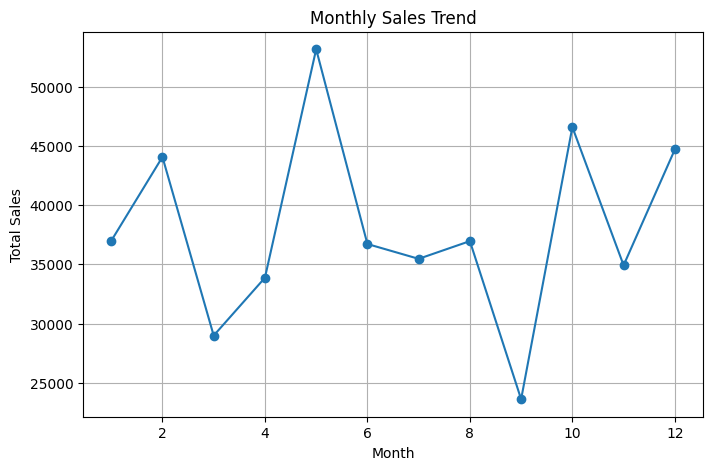

In [14]:
plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [31]:
## 4. Product Analysis – Category-wise Sales

In [16]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

print(category_sales)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


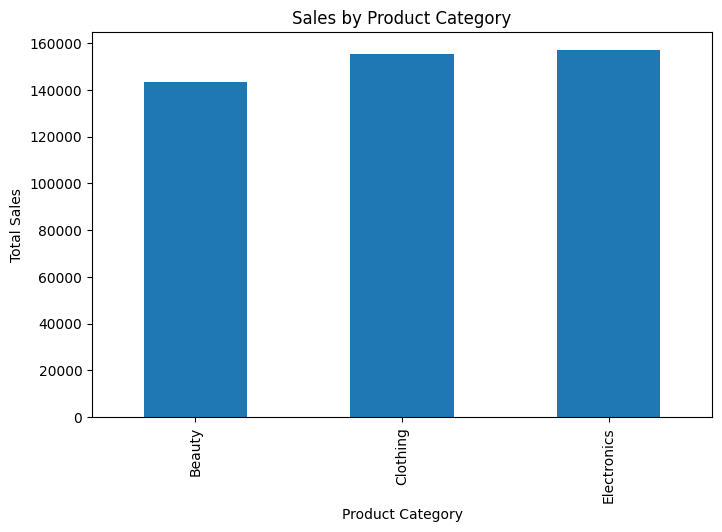

In [17]:
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.show()

In [18]:
df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

In [32]:
## 5. Customer Analysis – Gender-wise Sales

In [19]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


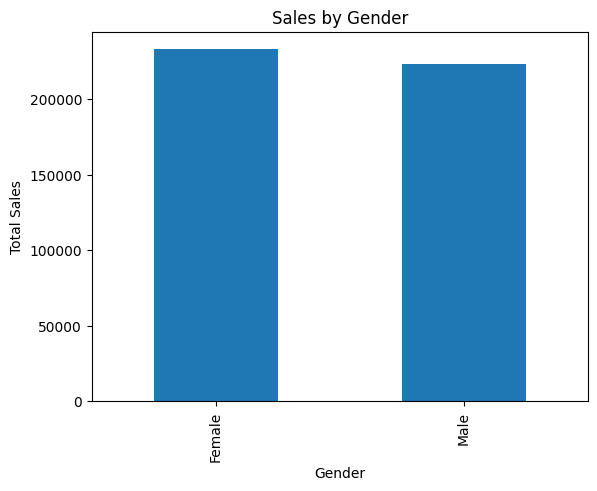

In [20]:
gender_sales.plot(kind='bar')
plt.title('Sales by Gender')
plt.ylabel('Total Sales')
plt.show()

In [33]:
## 6. Customer Analysis – Age Group Analysis

In [21]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0,20,30,40,50,100],
    labels=['<20','21-30','31-40','41-50','50+']
)

In [22]:
age_sales = df.groupby('Age Group', observed=False)['Total Amount'].sum()
print(age_sales)

Age Group
<20       34730
21-30     98215
31-40     95950
41-50     93795
50+      133310
Name: Total Amount, dtype: int64


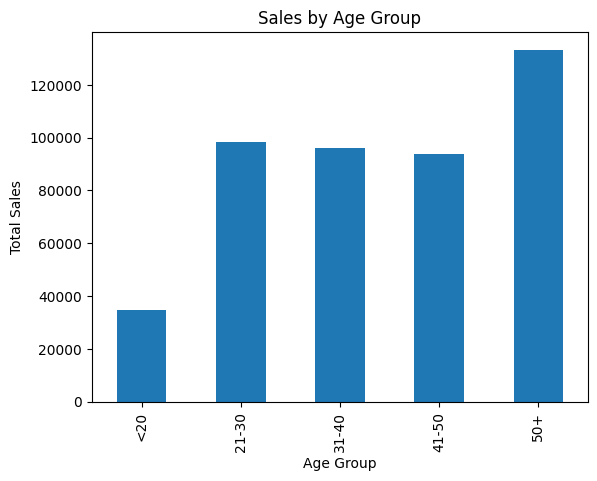

In [23]:
age_sales.plot(kind='bar')
plt.title('Sales by Age Group')
plt.ylabel('Total Sales')
plt.show()

In [34]:
## 7. Correlation Analysis using Heatmap

In [24]:
numeric_df = df[['Age','Quantity','Price per Unit','Total Amount']]

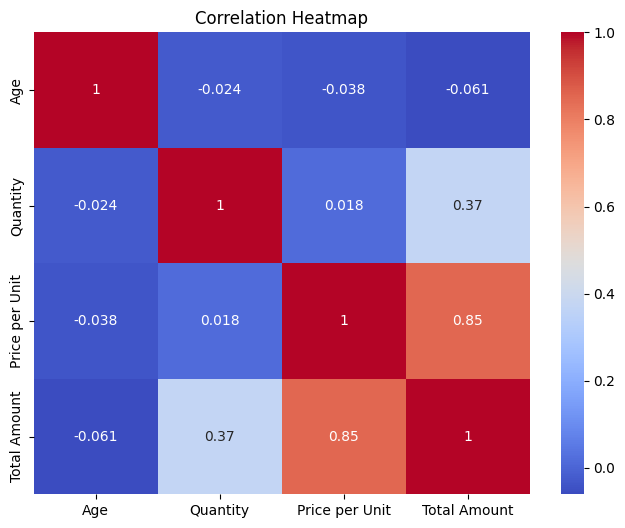

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [35]:
## 8. Sales Distribution Analysis

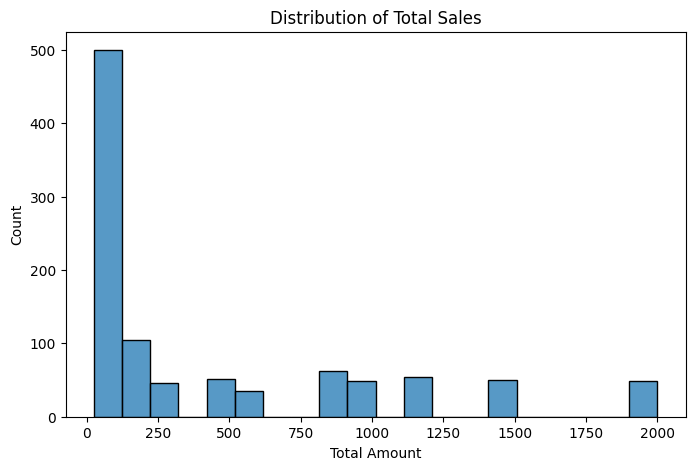

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Amount'], bins=20)
plt.title('Distribution of Total Sales')
plt.show()

In [36]:
## 9. Customer Purchase Behavior Analysis

In [27]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False)

print(top_customers.head(10))

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64
